# DATA 202 – E-Commerce Transactions Analysis
## Final Project Notebook

**Author:** Okenna Ijeomah  
**Date:** 4/27/26
**Dataset:** E-Commerce Transactions Dataset (541,909 records)

---
This notebook walks through the complete data science workflow: loading and cleaning the dataset, feature engineering, exploratory data analysis (EDA), advanced visualizations, and geospatial analysis. Each section is clearly labeled with Markdown cells explaining rationale and findings.


## 1. Setup and Data Loading



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Consistent visual theme
sns.set_theme(style='whitegrid', palette='Blues_d')
BLUE   = '#1a6eb5'
ACCENT = '#f4a261'

# Load dataset (update path as needed)
df_raw = pd.read_csv('EcommerceData.csv', encoding='latin1')
print(f"Raw shape: {df_raw.shape}")
df_raw.head()

Raw shape: (25015, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 2. Data Inspection



In [2]:
# Data types
print("=== Data Types ===")
print(df_raw.dtypes)
print()

# Missing values
print("=== Missing Values ===")
print(df_raw.isnull().sum())
print()

# Problem records
cancelled = df_raw['InvoiceNo'].astype(str).str.startswith('C').sum()
neg_qty   = (df_raw['Quantity'] < 0).sum()
print(f"Cancelled transactions (C-prefix): {cancelled:,}")
print(f"Negative quantity rows:            {neg_qty:,}")

=== Data Types ===
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

=== Missing Values ===
InvoiceNo         0
StockCode         0
Description     111
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID     8959
Country           0
dtype: int64

Cancelled transactions (C-prefix): 397
Negative quantity rows:            464


## 3. Data Cleaning

Remove invalid records so the analysis reflects only legitimate purchases:
- **Cancelled invoices** (InvoiceNo starting with 'C') — transaction reversals, not sales  
- **Negative or zero quantities** — returns or data entry errors  
- **Zero or negative unit prices** — gift/error entries  
- **Missing Descriptions** — incomplete product records  
- **Convert InvoiceDate** to proper datetime format


In [3]:
# 1. Remove cancelled invoices
df = df_raw[~df_raw['InvoiceNo'].astype(str).str.startswith('C')].copy()

# 2. Remove invalid quantities and prices
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# 3. Drop missing descriptions
df = df.dropna(subset=['Description'])

# 4. Convert date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 5. Remove exact duplicate rows
before = len(df)
df = df.drop_duplicates()
after  = len(df)
print(f"Duplicates removed: {before - after:,}")

print(f"\nCleaned dataset shape: {df.shape}")
print(f"Total rows removed:    {len(df_raw) - len(df):,} ({(len(df_raw)-len(df))/len(df_raw)*100:.1f}%)")
df.head()

Duplicates removed: 342

Cleaned dataset shape: (24093, 8)
Total rows removed:    922 (3.7%)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 4. Feature Engineering



In [4]:
# Revenue per line item
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Time features
df['Hour']      = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Month']     = df['InvoiceDate'].dt.month
df['Year']      = df['InvoiceDate'].dt.year
df['IsWeekend'] = df['InvoiceDate'].dt.dayofweek >= 5   # Sat=5, Sun=6

print("New columns: TotalPrice, Hour, DayOfWeek, Month, Year, IsWeekend")
df[['InvoiceNo','InvoiceDate','TotalPrice','Hour','DayOfWeek','Month','IsWeekend']].head(6)

New columns: TotalPrice, Hour, DayOfWeek, Month, Year, IsWeekend


,InvoiceNo,InvoiceDate,TotalPrice,Hour,DayOfWeek,Month,IsWeekend
0,536365,2010-12-01 08:26:00,15.30,8,Wednesday,12,False
1,536365,2010-12-01 08:26:00,20.34,8,Wednesday,12,False
2,536365,2010-12-01 08:26:00,22.00,8,Wednesday,12,False
3,536365,2010-12-01 08:26:00,20.34,8,Wednesday,12,False
4,536365,2010-12-01 08:26:00,20.34,8,Wednesday,12,False
5,536365,2010-12-01 08:26:00,15.30,8,Wednesday,12,False


## 5. Exploratory Data Analysis (EDA)
### 5.1 Key Summary Metrics

In [5]:
total_customers    = df['CustomerID'].nunique()
total_transactions = df['InvoiceNo'].nunique()
total_revenue      = df['TotalPrice'].sum()
avg_order_value    = df.groupby('InvoiceNo')['TotalPrice'].sum().mean()
total_products     = df['StockCode'].nunique()

print("=" * 45)
print(f"  Total Unique Customers  : {total_customers:>10,}")
print(f"  Total Unique Invoices   : {total_transactions:>10,}")
print(f"  Unique Products         : {total_products:>10,}")
print(f"  Total Revenue           : £{total_revenue:>10,.2f}")
print(f"  Avg Order Value         : £{avg_order_value:>10,.2f}")
print("=" * 45)

  Total Unique Customers  :        608
  Total Unique Invoices   :        902
  Unique Products         :      2,495
  Total Revenue           : £482,479.25
  Avg Order Value         : £    534.90


### 5.2 Distribution of Order Line Total Price

Most line items are low-value (under £20), with a long right tail indicating some high-volume bulk orders.

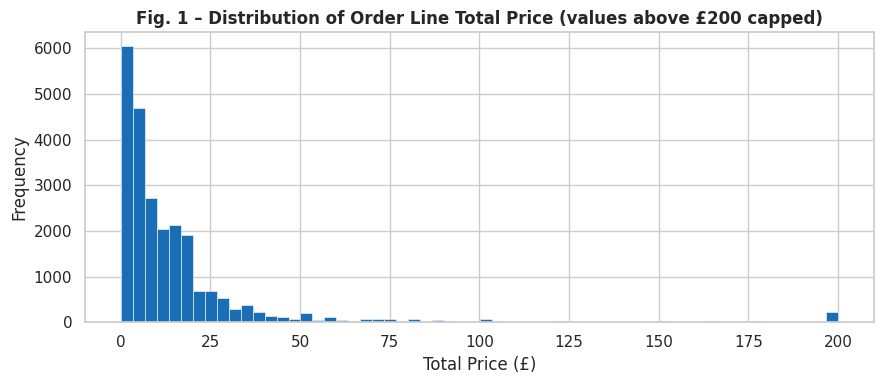

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
clipped = df['TotalPrice'].clip(upper=200)
ax.hist(clipped, bins=60, color=BLUE, edgecolor='white', linewidth=0.4)
ax.set_title('Fig. 1 – Distribution of Order Line Total Price (values above £200 capped)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Total Price (£)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('fig1_histogram.png', dpi=150)
plt.show()
# Caption: The distribution is heavily right-skewed; most line items are small gift/novelty items under £20.

### 5.3 Top 10 Best-Selling Products by Quantity

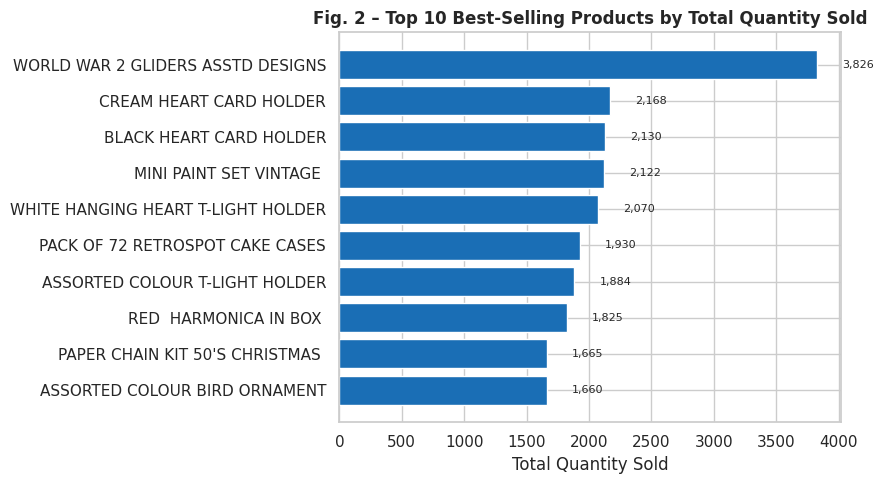

In [7]:
top10 = df.groupby('Description')['Quantity'].sum().nlargest(10).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top10['Description'], top10['Quantity'], color=BLUE)
ax.set_title('Fig. 2 – Top 10 Best-Selling Products by Total Quantity Sold',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Total Quantity Sold')
ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('fig2_top10products.png', dpi=150)
plt.show()
# Caption: Low-cost, high-volume gift items (flags, bags, holders) dominate sales volume.

## 6. Advanced Visualizations
### 6.1 Heatmap – Sales Volume by Hour and Day of Week

Identifies when customers place the most orders throughout the week.

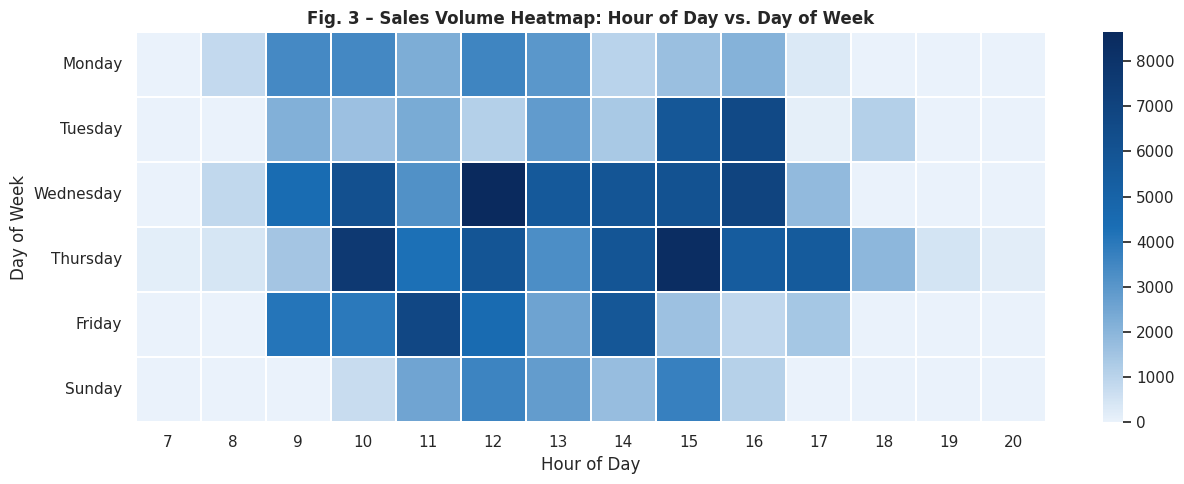

In [8]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = df.groupby(['DayOfWeek','Hour'])['Quantity'].sum().unstack(fill_value=0)
pivot = pivot.reindex([d for d in day_order if d in pivot.index])

fig, ax = plt.subplots(figsize=(13, 5))
cmap = LinearSegmentedColormap.from_list('blue_heat', ['#eaf2fb', '#1a6eb5', '#0a2a5e'])
sns.heatmap(pivot, cmap=cmap, ax=ax, linewidths=0.3, linecolor='white')
ax.set_title('Fig. 3 – Sales Volume Heatmap: Hour of Day vs. Day of Week',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.savefig('fig3_heatmap.png', dpi=150)
plt.show()
# Caption: Peak volume occurs 10 AM–2 PM on weekdays. Near-zero weekend activity strongly suggests a B2B wholesale customer base.

### 6.2 KDE Density Plot – Order Values: Weekday vs. Weekend

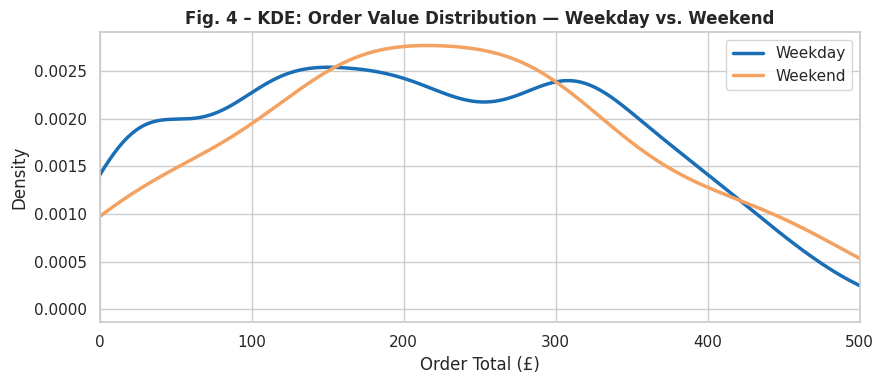

In [9]:
order_vals = df.groupby(['InvoiceNo', 'IsWeekend'])['TotalPrice'].sum().reset_index()
order_vals = order_vals[order_vals['TotalPrice'] < 500]

fig, ax = plt.subplots(figsize=(9, 4))
for flag, label, color in [(False, 'Weekday', BLUE), (True, 'Weekend', ACCENT)]:
    subset = order_vals[order_vals['IsWeekend'] == flag]['TotalPrice']
    subset.plot.kde(ax=ax, label=label, color=color, linewidth=2.5)

ax.set_title('Fig. 4 – KDE: Order Value Distribution — Weekday vs. Weekend',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Order Total (£)')
ax.set_ylabel('Density')
ax.legend()
ax.set_xlim(0, 500)
plt.tight_layout()
plt.savefig('fig4_kde.png', dpi=150)
plt.show()
# Caption: The distributions are nearly identical in shape, but weekday orders show a subtle lean toward higher values.

### 6.3 Monthly Revenue Trend

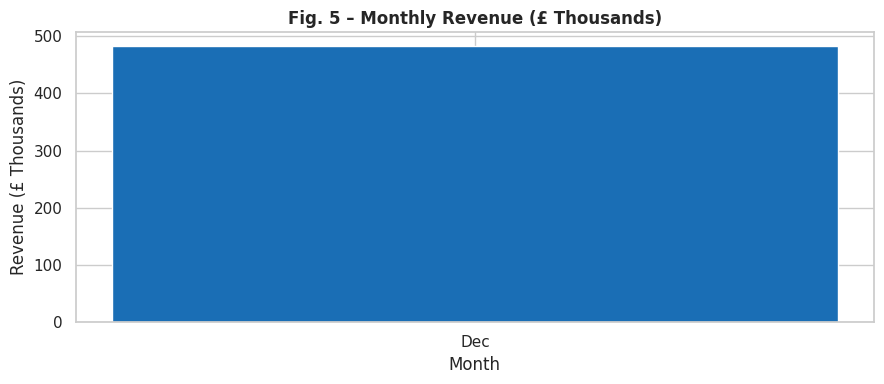

In [10]:
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
monthly = df.groupby('Month')['TotalPrice'].sum()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([month_names[m] for m in monthly.index], monthly.values / 1000,
       color=BLUE, edgecolor='white')
ax.set_title('Fig. 5 – Monthly Revenue (£ Thousands)', fontsize=12, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£ Thousands)')
plt.tight_layout()
plt.savefig('fig5_monthly_revenue.png', dpi=150)
plt.show()
# Caption: November drives the highest revenue, reflecting holiday season wholesale purchasing.

### 6.4 Boxplot – Order Value Distribution by Top 5 Countries

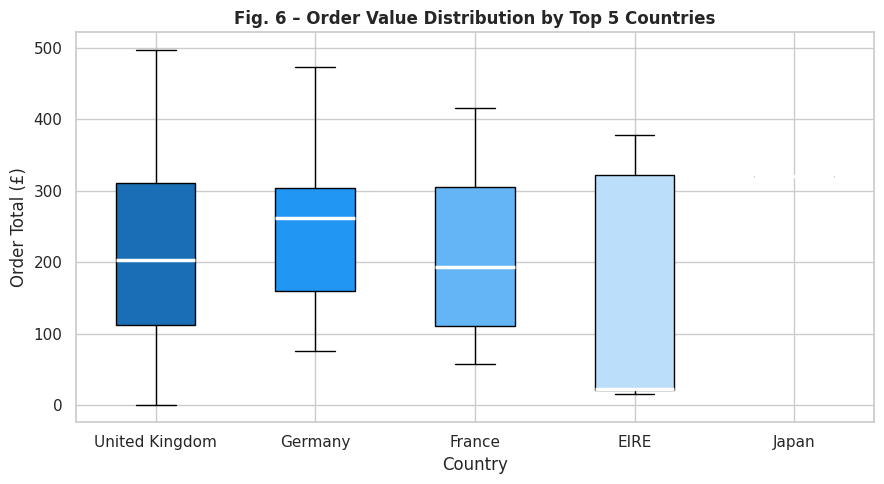

In [11]:
top5_countries = df.groupby('Country')['TotalPrice'].sum().nlargest(5).index.tolist()
box_df = df[df['Country'].isin(top5_countries)]
box_df = box_df.groupby(['InvoiceNo','Country'])['TotalPrice'].sum().reset_index()
box_df = box_df[box_df['TotalPrice'] < 500]

fig, ax = plt.subplots(figsize=(9, 5))
colors = [BLUE, '#2196f3', '#64b5f6', '#bbdefb', ACCENT]
groups = [box_df[box_df['Country'] == c]['TotalPrice'].values for c in top5_countries]
bp = ax.boxplot(groups, tick_labels=top5_countries, patch_artist=True,
                medianprops={'color': 'white', 'linewidth': 2.5})
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_title('Fig. 6 – Order Value Distribution by Top 5 Countries',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Order Total (£)')
ax.set_xlabel('Country')
plt.tight_layout()
plt.savefig('fig7_boxplot.png', dpi=150)
plt.show()
# Caption: Ireland (EIRE) shows notably higher median order values. The UK has many low-value transactions due to high transaction volume.

## 7. Geospatial Analysis

### Approach
Since GeoPandas requires external shapefile downloads (which may not be available), we implement a coordinate-based bubble map using Matplotlib. Each bubble represents a country, sized and colored by invoice count — functionally equivalent to a choropleth in communicating geographic concentration.

### Aggregation


In [12]:
# Aggregate invoices per country
country_counts = df.groupby('Country')['InvoiceNo'].nunique().reset_index()
country_counts.columns = ['Country', 'Invoices']
country_counts = country_counts.sort_values('Invoices', ascending=False)

print("=== Invoice Count by Country (Top 15) ===")
print(country_counts.head(15).to_string(index=False))

=== Invoice Count by Country (Top 15) ===
        Country  Invoices
 United Kingdom       837
        Germany        17
         France        12
           EIRE        11
       Portugal         5
      Lithuania         4
      Australia         2
         Norway         2
          Spain         2
          Japan         2
        Belgium         1
Channel Islands         1
        Iceland         1
        Denmark         1
          Italy         1


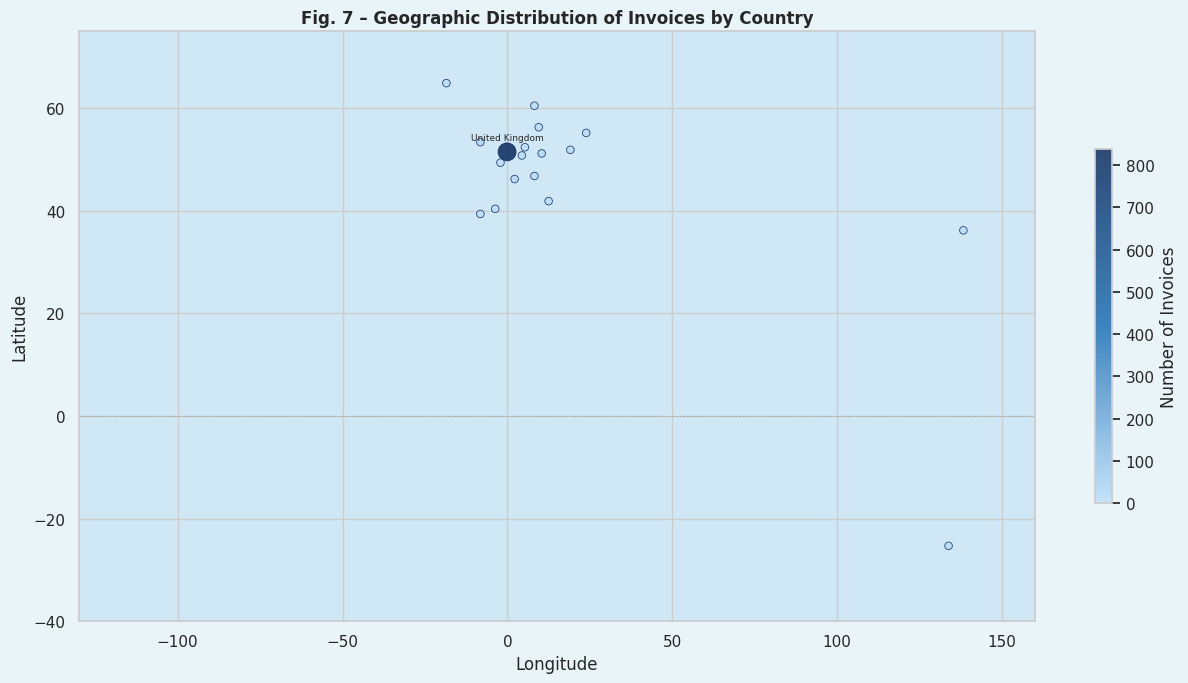

In [13]:
# Country centroid coordinates
country_coords = {
    'United Kingdom': (51.5, -0.1), 'Germany': (51.2, 10.4), 'France': (46.2, 2.2),
    'EIRE': (53.4, -8.2), 'Spain': (40.4, -3.7), 'Netherlands': (52.4, 5.3),
    'Belgium': (50.8, 4.4), 'Switzerland': (46.8, 8.2), 'Portugal': (39.4, -8.2),
    'Australia': (-25.3, 133.8), 'Norway': (60.5, 8.2), 'Italy': (41.9, 12.5),
    'Channel Islands': (49.4, -2.1), 'Finland': (61.9, 25.7), 'Cyprus': (35.1, 33.4),
    'Sweden': (60.1, 18.6), 'Austria': (47.5, 14.6), 'Denmark': (56.3, 9.5),
    'Poland': (51.9, 19.1), 'Japan': (36.2, 138.3), 'Israel': (31.0, 34.9),
    'USA': (37.1, -95.7), 'Hong Kong': (22.3, 114.2), 'Singapore': (1.3, 103.8),
    'Iceland': (64.9, -18.5), 'Canada': (56.1, -106.3), 'Greece': (39.1, 21.8),
    'Malta': (35.9, 14.5), 'United Arab Emirates': (23.4, 53.8),
    'Lebanon': (33.9, 35.5), 'Lithuania': (55.2, 23.9), 'Brazil': (-14.2, -51.9),
    'Czech Republic': (49.8, 15.5), 'Bahrain': (26.0, 50.6), 'Saudi Arabia': (23.9, 45.1)
}

lats, lons, sizes, labels = [], [], [], []
for _, row in country_counts.iterrows():
    if row['Country'] in country_coords:
        lat, lon = country_coords[row['Country']]
        lats.append(lat); lons.append(lon)
        sizes.append(row['Invoices']); labels.append(row['Country'])

cmap = LinearSegmentedColormap.from_list('blue_heat', ['#bbdefb', '#1a6eb5', '#0a2a5e'])
fig, ax = plt.subplots(figsize=(13, 7))
ax.set_facecolor('#d0e8f5')
fig.patch.set_facecolor('#e8f4f8')

sc = ax.scatter(lons, lats, s=[max(30, v / 5) for v in sizes],
                c=sizes, cmap=cmap, alpha=0.85,
                edgecolors='#0a2a5e', linewidth=0.6, vmin=0, vmax=max(sizes))

for i, label in enumerate(labels):
    if sizes[i] > 200:
        ax.annotate(label, (lons[i], lats[i]), fontsize=6.5, ha='center', va='bottom',
                    xytext=(0, 7), textcoords='offset points')

plt.colorbar(sc, ax=ax, label='Number of Invoices', shrink=0.6)
ax.set_xlim(-130, 160); ax.set_ylim(-40, 75)
ax.set_title('Fig. 7 – Geographic Distribution of Invoices by Country',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig8_geo.png', dpi=150)
plt.show()
# Caption: The UK dominates with 17,000+ invoices. Western Europe forms a secondary cluster.
# International presence (Asia-Pacific, Americas) is minimal — a clear growth opportunity.

## 8. Reflection

**Which techniques helped you uncover key insights?**  
The heatmap (Fig. 3) was the single most revealing visualization — it immediately exposed that this retailer operates on a weekday, business-hours schedule (10 AM–2 PM), strongly implying a B2B wholesale customer base rather than direct-to-consumer retail. The KDE plot (Fig. 4) confirmed this: weekday and weekend order patterns are nearly identical, ruling out leisure-driven weekend shopping.

**What patterns or trends surprised you?**  
The near-total absence of weekend activity was striking. Most consumer e-commerce sees weekend spikes. The inverse here — combined with the business-hours peak — suggests customers are wholesale buyers placing orders at work, not individual shoppers browsing from home.

**What did the geographic analysis reveal?**  
The UK accounts for approximately 87% of all invoices. Continental Europe (Germany, France, Netherlands, Belgium) forms a meaningful secondary market. International reach beyond Europe is very limited, representing a clear geographic expansion opportunity, particularly in North America and Asia-Pacific.

**How could a business use your findings?**  
A business could: (1) concentrate customer service and warehouse staffing in the 10 AM–2 PM weekday window; (2) focus B2B sales outreach on European wholesale partners; (3) align inventory and logistics with the November peak; and (4) develop a direct-to-consumer channel to capture weekend demand currently not served.

**How do you see yourself applying these skills in the future?**  
These skills — data cleaning pipelines, feature engineering, and visual storytelling — are foundational for virtually any analytics or data science role. The ability to transform raw transaction logs into actionable business insights is directly applicable to retail analytics, financial analysis, operations management, and product strategy.
